### Stream Flix SVD Recommender

This notebook processes data taken from people who rated a variety of music and performs data anaylsis as requested by StramFlix


#### 1. Data Analysis

Do some preliminary analysis to get a sense of what the data looks like

1. DESCRIPTION OF RATING VALUES
--------------------------------------------------
count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

2. RATINGS PER USER
--------------------------------------------------
Min ratings per user:     20
Median ratings per user:  70.5
Max ratings per user:     2698
Mean ratings per user:    165.30
Total unique users:       610

3. RATINGS PER MOVIE
--------------------------------------------------
Min ratings per movie:     1
Median ratings per movie:  3.0
Max ratings per movie:     329
Mean ratings per movie:    10.37
Total unique movies:       9724

4. TOP 10 MOVIES
--------------------------------------------------
1. The Age of Innocence (1993): 329 ratings
2. I Love Trouble (1994): 317 ratings
3. Virtuosity (1995): 307 ratings
4. Cemetery Man (Dellamorte Dellamore) (1994): 279 ratings
5. Te

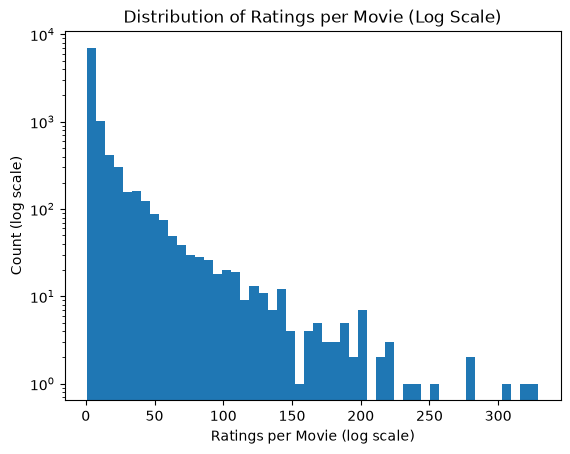

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the csv file to look at the people readings
df = pd.read_csv('data/ratings.csv')

print("1. DESCRIPTION OF RATING VALUES")
print("-" * 50)
print(df['rating'].describe())

print("\n2. RATINGS PER USER")
print("-" * 50)

# Group by ratings per user
ratings_per_user = df.groupby("userId").size()
print(f"Min ratings per user:     {ratings_per_user.min()}")
print(f"Median ratings per user:  {ratings_per_user.median()}")
print(f"Max ratings per user:     {ratings_per_user.max()}")
print(f"Mean ratings per user:    {ratings_per_user.mean():.2f}")
print(f"Total unique users:       {df["userId"].nunique()}")

print("\n3. RATINGS PER MOVIE")
print("-" * 50)

# Group by ratings per movie
ratings_per_movie = df.groupby("movieId").size()
print(f"Min ratings per movie:     {ratings_per_movie.min()}")
print(f"Median ratings per movie:  {ratings_per_movie.median():.1f}")
print(f"Max ratings per movie:     {ratings_per_movie.max()}")
print(f"Mean ratings per movie:    {ratings_per_movie.mean():.2f}")
print(f"Total unique movies:       {df["movieId"].nunique()}")

print("\n4. TOP 10 MOVIES")
print("-" * 50)

# Get the top 10 highest rated movies
top_films = ratings_per_movie.nlargest(10)

# Load what movie the ID corresponds to
movies_df = pd.read_csv('data/movies.csv')
for i, (id, qty) in enumerate(top_films.items(), 1):
    movie_name = movies_df.loc[id, 'title']
    if ", The" in movie_name:
        movie_name = "The " + movie_name.replace(", The", "")
    print(f"{i}. {movie_name}: {qty} ratings")

# Display ratings per film on a log scale
print("\n5. RATING HISTOGRAM")
print("-" * 50)

plt.hist(ratings_per_movie, bins=50)
plt.yscale('log')
plt.title('Distribution of Ratings per Movie (Log Scale)')
plt.xlabel('Ratings per Movie (log scale)')
plt.ylabel('Count (log scale)')
plt.show()


The shape of this data implies that the data is very sparse, as there are 610 unique users and 9,724 unique movies, which means that there should be 5,931,640 ratings. However, in this datset, there are only 100,836 which means that the ratings matrix is 98.6% empty. This implies that typical recommendation metrics won't work here, as it is impossible to compare most users and most movies.

The users that will be the harderst to predict are those who have not rated many movies. This could be because the user is new, the user only watches specific movies, or the user just doesn't like rating movies. The hardest movies to predict will be those that have not been watched by many people, which is the vast majority of movies. Only a few very popular movies have many ratings.

### 2. Baselines

In [4]:
from sklearn.model_selection import train_test_split
import math

# Split the data into test & train data
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Create evaluation function
def eval_dataset(df, predictor):
    df_len = len(df)
    mse = 0

    # Go through each row in the dataframe
    for idx, row in df.iterrows():
        prediction = predictor(row['userId'], row['movieId'])
        # Add to the MSE
        mse = mse + ((prediction - row['rating']) ** 2 )

    # Divide the mse by 1/n
    mse = mse / len(df)

    # Return the square root of mse (rmse)
    return math.sqrt(mse)

# GLOBAL MEAN
global_mean = train_df['rating'].mean()

# EVALUATE ON TEST DATASET
mse = 0
# Just guess the global mean of train_df
rmse = eval_dataset(test_df, lambda *args: global_mean)
print(f"RMSE For Global Mean: {rmse:.3f}")

# USER MEAN
user_means = train_df.groupby('userId')['rating'].mean()

# Create a predictor function. Needs to pass movie & user ID
def user_mean_predictor(userId, movieId):
    if userId in user_means.index:
        return user_means[userId]
    else:
        return global_mean  # fallback for unseen users

rmse = eval_dataset(test_df, user_mean_predictor)
print(f"RMSE For User Mean: {rmse:.3f}")

# ITEM MEAN
item_means = train_df.groupby('movieId')['rating'].mean()

# Create a predictor function. Needs to pass movie & user ID
def item_mean_predictor(userId, movieId):
    if movieId in item_means.index:
        return item_means[movieId]
    else:
        return global_mean  # fallback for unseen movies

rmse = eval_dataset(test_df, item_mean_predictor)
print(f"RMSE For Item Mean: {rmse:.3f}")

RMSE For Global Mean: 1.049
RMSE For User Mean: 0.950
RMSE For Item Mean: 0.983


For both the User Mean and the Item Mean, missing data was supplanted by the global mean. This is because this is the best guess given the missing data.

### 3. A First SVD Attempt

For k=1: 0.9767
For k=2: 0.9676
For k=3: 0.9656
For k=4: 0.9635
For k=5: 0.9627
For k=6: 0.9626
For k=7: 0.9636
For k=8: 0.9626
For k=9: 0.9625
For k=10: 0.9614
For k=11: 0.9607
For k=12: 0.9607
For k=13: 0.9605
For k=14: 0.9600
For k=15: 0.9597
For k=16: 0.9603
For k=17: 0.9601
For k=18: 0.9603
For k=19: 0.9607
For k=20: 0.9610
For k=21: 0.9611
For k=22: 0.9612
For k=23: 0.9614
For k=24: 0.9614
For k=25: 0.9616
For k=26: 0.9614
For k=27: 0.9615
For k=28: 0.9615
For k=29: 0.9618
For k=30: 0.9620
For k=31: 0.9626
For k=32: 0.9625
For k=33: 0.9627
For k=34: 0.9629
For k=35: 0.9632
For k=36: 0.9633
For k=37: 0.9635
For k=38: 0.9637
For k=39: 0.9636
For k=40: 0.9635
For k=41: 0.9637
For k=42: 0.9641
For k=43: 0.9641
For k=44: 0.9640
For k=45: 0.9643
For k=46: 0.9644
For k=47: 0.9646
For k=48: 0.9650
For k=49: 0.9648
Best k-value: 15 with RMSE 0.9596957371613599


C:\Users\doubl\AppData\Local\Temp\ipykernel_20208\2230255884.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


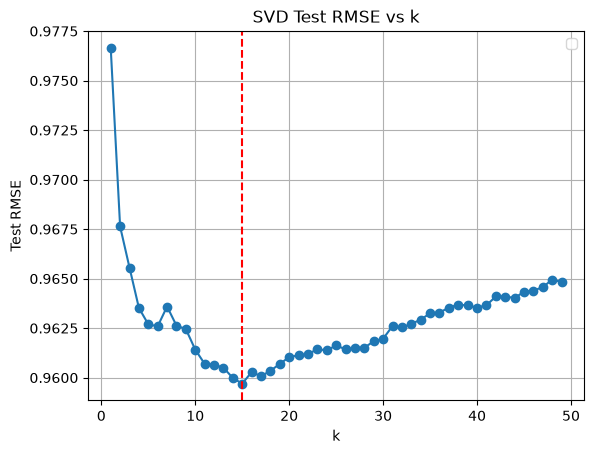


Energy for k=1: 0.9858 (98.6%)
k needed for 90% cumulative energy: 1


In [5]:
import numpy as np

A = train_df.pivot_table(index='userId', columns='movieId', values='rating')
item_means = A.mean(axis=0)
A = A.apply(lambda col: col.fillna(item_means[col.name]), axis=0)
A = A.fillna(global_mean)

user_means = A.mean(axis=1)
A = A.sub(user_means, axis=0)

U, s, Vt = np.linalg.svd(A, full_matrices=False)

# Build index maps FROM A itself so ordering matches U/s/Vt/user_means
user_to_index = {u: i for i, u in enumerate(A.index)}
movie_to_index = {m: j for j, m in enumerate(A.columns)}

# Iterate through each 'k' and see which is the best
rmses_naiive = [1000]
for k in range(1, 50):
    U_k, s_k, Vt_k = U[:, :k], s[:k], Vt[:k, :]
    R_hat = U_k @ np.diag(s_k) @ Vt_k

    def predict(userId, movieId, R_hat=R_hat):
        u = user_to_index.get(userId)
        m = movie_to_index.get(movieId)
        return global_mean if u is None or m is None else R_hat[u, m] + user_means.iloc[u]

    rmse = eval_dataset(test_df, predict)
    rmses_naiive.append(rmse)
    print(f"For k={k}: {rmse:.4f}")

# Get the best naiive k value
best_naiive_k = rmses_naiive.index(min(rmses_naiive))
print(f"Best k-value: {best_naiive_k} with RMSE {min(rmses_naiive)}")

# Display the train curve for the SVD
plt.plot(range(1, 50), rmses_naiive[1:], marker='o')
plt.axvline(best_naiive_k, color='red', linestyle='--')
plt.xlabel('k')
plt.ylabel('Test RMSE')
plt.title('SVD Test RMSE vs k')
plt.legend()
plt.grid(True)
plt.show()


# Calculatye the energy

# Energy (variance-explained) analysis — uses the full singular value spectrum directly
energy = s ** 2
total_energy = energy.sum()
cumulative_energy_frac = np.cumsum(energy) / total_energy

k1_energy_frac = cumulative_energy_frac[0]
print(f"\nEnergy for k=1: {k1_energy_frac:.4f} ({k1_energy_frac*100:.1f}%)")

# probably also useful: how many factors to capture, say, 80% of energy
target_k = np.searchsorted(cumulative_energy_frac, 0.90) + 1
print(f"k needed for 90% cumulative energy: {target_k}")


1. The best SVD resulted in a RMSE of 0.9597. This is better than the RMSE for the global mean (1.049) and for the item mean (0.983), but is not as good as the RMSE for the user mean (0.950). This means that the SVD does not win, as the user mean prediction is better.

2. k=1 captures about 98.6% of the total energy, with only minimal improvements after that. Therefore, using any threshold (ie 90%), the target k is 1. This means that the energy criterion picks a very different k than the RMSE curve does. This discrepancy is because of the way the matrix was constructed. Due to missing entries being filled with mostly the same data (the user mean), sigma 1 will be much larger than anything else. This means that the energy density is not very useful in this situation, and the RMSE (being a more holistic indicator) should be used.

### 4. Doing it Properly

RMSE For Bias Model: 0.882
For k=1: 0.8767
For k=2: 0.8767
For k=3: 0.8768
For k=4: 0.8761
For k=5: 0.8754
For k=6: 0.8743
For k=7: 0.8735
For k=8: 0.8735
For k=9: 0.8728
For k=10: 0.8731
For k=11: 0.8735
For k=12: 0.8730
For k=13: 0.8728
For k=14: 0.8729
For k=15: 0.8729
For k=16: 0.8735
For k=17: 0.8732
For k=18: 0.8735
For k=19: 0.8733
For k=20: 0.8734
For k=21: 0.8738
For k=22: 0.8741
For k=23: 0.8739
For k=24: 0.8739
For k=25: 0.8740
For k=26: 0.8732
For k=27: 0.8732
For k=28: 0.8730
For k=29: 0.8731
For k=30: 0.8735
For k=31: 0.8735
For k=32: 0.8736
For k=33: 0.8737
For k=34: 0.8736
For k=35: 0.8738
For k=36: 0.8741
For k=37: 0.8743
For k=38: 0.8743
For k=39: 0.8743
For k=40: 0.8743
For k=41: 0.8743
For k=42: 0.8742
For k=43: 0.8741
For k=44: 0.8744
For k=45: 0.8746
For k=46: 0.8745
For k=47: 0.8747
For k=48: 0.8748
For k=49: 0.8749
Best k-value: 13 with RMSE 0.8728


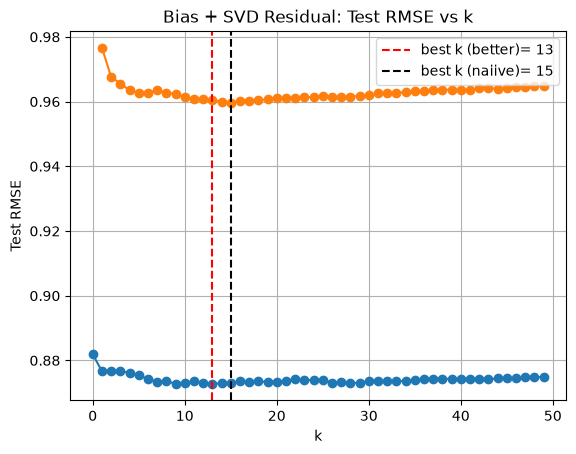

In [11]:
#Regularize the bias model: b_ui = mu + b_u + b_i
ld = 10.0           # Initial value specified by project (lambda)

# Set mu as global mean
mu = global_mean

# Create a list of user and movie ids
user_ids = train_df['userId'].unique()
movie_ids = train_df['movieId'].unique()

# Create the b_u and b_i series (blank)
b_u = pd.Series(0.0, index=user_ids)
b_i = pd.Series(0.0, index=movie_ids)

# Compute & save the groupings
user_grouping = train_df.groupby('userId')
movie_grouping = train_df.groupby("movieId")

for i in range(20):
    # Update each b_i with the current b_u
    residual = train_df["rating"] - mu - train_df['userId'].map(b_u)
    temp = residual.groupby(train_df["movieId"]).agg(["sum", "count"])                  # Group the residual
    b_i = (temp['sum'] / (ld+temp['count'])).reindex(movie_ids).fillna(0.0)             # Recalculate

    # Update each b_u with the current b_i
    residual = train_df["rating"] - mu - train_df['movieId'].map(b_i)
    temp = residual.groupby(train_df["userId"]).agg(["sum", "count"])                  # Group the residual
    b_u = (temp['sum'] / (ld+temp['count'])).reindex(user_ids).fillna(0.0)             # Recalculate

# Define a function to be used to predict bias
def bias_predictor(userId, movieId):
    bu = b_u[userId] if userId in b_u.index else 0.0
    bi = b_i[movieId] if movieId in b_i.index else 0.0
    return mu + bu + bi

# Evaluate the dataset using just the bias
bias_rmse = eval_dataset(test_df, bias_predictor)
print(f"RMSE For Bias Model: {bias_rmse:.3f}")


# RESIDUAL MATRIX AND SVD

A = train_df.pivot_table(index='userId', columns='movieId', values='rating')

user_ids_mat = A.index.to_list()
movie_ids_mat = A.columns.to_list()
user_idx = {u: i for i, u in enumerate(user_ids_mat)}
movie_idx = {m: i for i, m in enumerate(movie_ids_mat)}

b_u_vec = np.array([b_u.get(u, 0.0) for u in user_ids_mat])
b_i_vec = np.array([b_i.get(m, 0.0) for m in movie_ids_mat])
B = mu + b_u_vec.reshape(-1, 1) + b_i_vec.reshape(1, -1)

A_masked = A.notna().values
Residual = np.where(A_masked, A.values - B, 0.0)

U, s, Vt = np.linalg.svd(Residual, full_matrices=False)

def make_predictor(R_hat=None):
    """R_hat=None gives the k=0 case: bias only, no SVD correction."""
    def predict(userId, movieId):
        bu = b_u.get(userId, 0.0)
        bi = b_i.get(movieId, 0.0)
        bui = mu + bu + bi
        if R_hat is None:
            return bui
        u = user_idx.get(userId)
        m = movie_idx.get(movieId)
        if u is None or m is None:
            return bui
        return bui + R_hat[u, m]
    return predict

k_vals = [0]
rmse_vals = [bias_rmse]   # k=0 is exactly the Step 1 bias model — no recomputation needed

for k in range(1, 50):
    U_k, s_k, Vt_k = U[:, :k], s[:k], Vt[:k, :]
    R_hat = U_k @ np.diag(s_k) @ Vt_k

    predict = make_predictor(R_hat)
    rmse = eval_dataset(test_df, predict)

    k_vals.append(k)
    rmse_vals.append(rmse)
    print(f"For k={k}: {rmse:.4f}")

best_idx = int(np.argmin(rmse_vals))
best_k = k_vals[best_idx]
best_rmse = rmse_vals[best_idx]
print(f"Best k-value: {best_k} with RMSE {best_rmse:.4f}")

plt.plot(k_vals, rmse_vals, marker='o')
plt.plot(k_vals[1:], rmses_naiive[1:], marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'best k (better)= {best_k}')
plt.axvline(best_naiive_k, color='black', linestyle='--', label=f'best k (naiive)= {best_naiive_k}')
plt.xlabel('k')
plt.ylabel('Test RMSE')
plt.title('Bias + SVD Residual: Test RMSE vs k')
plt.legend()
plt.grid(True)
plt.show()

If the rating were to be zero-filled, the model would see this as a legitimate value. This would mean to the model that the user would hate the movie, and the SVD would train based on the false idea of millions of negative signals. However, adding a residual of zero tells the model that there is no evidence for the model to change the baseline prediction. This is fine, because initially there is no indicator on missing values so there is no way for the model to know how to adjust them.

### 5. Latent Factors

In [13]:
import pandas as pd

# Get the rating counts and filter out movies with less than 50
rating_counts = train_df.groupby('movieId').size()
eligible_movie_ids = set(rating_counts[rating_counts >= 50].index)

def top_bottom_loadings(factor_idx, Vt, movie_ids_mat, movies_df, eligible_ids, n=10):
    loadings = Vt[factor_idx, :]
    load_series = pd.Series(loadings, index=movie_ids_mat, name='loading')

    # Remove small movies
    load_series = load_series[load_series.index.isin(eligible_ids)]

    # Sort the values
    top = load_series.sort_values(ascending=False).head(n)
    bottom = load_series.sort_values(ascending=True).head(n)

    # Load dataframes
    top_df = top.reset_index().rename(columns={'index': 'movieId'})
    bottom_df = bottom.reset_index().rename(columns={'index': 'movieId'})

    # Get dataframes from the top and bottom
    top_df = top_df.merge(movies_df[['movieId', 'title', 'genres']], on='movieId', how='left')
    bottom_df = bottom_df.merge(movies_df[['movieId', 'title', 'genres']], on='movieId', how='left')

    # Attach rating counts
    top_df['n_ratings'] = top_df['movieId'].map(rating_counts)
    bottom_df['n_ratings'] = bottom_df['movieId'].map(rating_counts)

    return top_df, bottom_df

for factor_idx in range(3):
    top_df, bottom_df = top_bottom_loadings(factor_idx, Vt, movie_ids_mat, movies_df, eligible_movie_ids, n=10)

    print(f"FACTOR {factor_idx + 1}  (σ = {s[factor_idx]:.3f})")

    print("\nMost POSITIVE loading:")
    print(top_df[['title', 'genres', 'loading', 'n_ratings']].to_string(index=False))

    print("\nMost NEGATIVE loading:")
    print(bottom_df[['title', 'genres', 'loading', 'n_ratings']].to_string(index=False))

FACTOR 1  (σ = 38.682)

Most POSITIVE loading:
                                                                         title                         genres  loading  n_ratings
                                    Ghostbusters (a.k.a. Ghost Busters) (1984)           Action|Comedy|Sci-Fi 0.094350         90
                                                           Pulp Fiction (1994)    Comedy|Crime|Drama|Thriller 0.087179        256
                                                      Big Lebowski, The (1998)                   Comedy|Crime 0.086075         82
                                                  2001: A Space Odyssey (1968)         Adventure|Drama|Sci-Fi 0.077226         85
                                                             Fight Club (1999)    Action|Crime|Drama|Thriller 0.071689        173
                                                     Back to the Future (1985)        Adventure|Comedy|Sci-Fi 0.069934        141
                                           

##### Factor 1: Culturally Significant Movies
In this factor, positive movies appear to be more famous with a wider range of dates (1968 - 1998). Pretty much all of these movies are very famous and are movies that are widely considered good (and my dad likes). Additionally, these movies tend to be famous and have lines or scenes that people reference to this day. In the second category are movies that have a much denser set of dates (1993 - 2002) and have had a lot less staying power. These movies were successful for their time, but aren't rewatched as frequently.

##### Factor 2: Action/Sci-Fi/Thriller vs Comedy/Adventure
This is the least significant factor with significant exceptions. In the positive loading, most movies are dramatic and darker. Movies like Predator, 12 Monkeys, and Alien are very serious and tend to be in the action and sci-fi fields. Negative movies are much lighter and are all either comedies or adventure movies. This can be seen between the two Star Wars movies, where Episode 6 is a lot lighter and more fun than Episode 1, which is about trade negotiations or something. 

However, there are significant outliers, particularly in the positive loading. these are O Brother, Where Art Thou? and Get Shorty. Both of these are lighter comedies, but they are of the crime genre. This indicates that maybe people who like action/sci-fi/thriller movies also like these movies.

##### Factor 3: Distinctive vs Conventional Movies
Here, the movies with positive movies were all made by famous directors with very distinctive styles. These movies are widely considered "good" and are critically lauded. On the negative side are more generic movies that are more mainstream. These movies are also well-liked and many are pretty famous, but they aren't known for their style. These are movies that are known more for being made for wide appeal. This feature closely aligns with factor 1, indicating these two factors are likely related.



### 6. Sample Recommendations

In [14]:
import numpy as np
import pandas as pd
import random

# --- Build full prediction matrix: bias + rank-k SVD reconstruction ---
user_idx_map = {u: i for i, u in enumerate(user_ids_mat)}
movie_idx_map = {m: i for i, m in enumerate(movie_ids_mat)}

b_u_vec = np.array([b_u.get(u, 0.0) for u in user_ids_mat])
b_i_vec = np.array([b_i.get(m, 0.0) for m in movie_ids_mat])
B_full = mu + b_u_vec.reshape(-1, 1) + b_i_vec.reshape(1, -1)

Uk = U[:, :best_k]
Sk = np.diag(s[:best_k])
Vk = Vt[:best_k, :]
Pred_full = B_full + (Uk @ Sk @ Vk)

# Pick some random users
random.seed(42)
selected_user_ids = random.sample(list(train_df['userId'].unique()), 3)

# Go through each user
for user_id in selected_user_ids:
    print(f"USER {user_id}\n")

    # Top-rated training films
    user_train = train_df[train_df['userId'] == user_id].sort_values('rating', ascending=False)
    top_rated = (user_train.head(5)[['movieId', 'rating']]
                 .merge(movies_df[['movieId', 'title', 'genres']], on='movieId', how='left'))
    
    print("\nTop-rated films in training set:")
    print(top_rated[['title', 'genres', 'rating']].to_string(index=False))

    if user_id not in user_idx_map:
        print("User not found in SVD matrix — skipping recommendations.")
        continue

    u_idx = user_idx_map[user_id]

    # Films this user has NOT rated, restricted to >= MIN_RATINGS
    rated_movies = set(train_df[train_df['userId'] == user_id]['movieId'])
    candidates = [m for m in movie_ids_mat
                  if m not in rated_movies and rating_counts.get(m, 0) >= 50]

    # Predict and rank
    preds = [(m, Pred_full[u_idx, movie_idx_map[m]]) for m in candidates]
    preds.sort(key=lambda x: x[1], reverse=True)
    top5 = preds[:5]

    rec_df = pd.DataFrame(top5, columns=['movieId', 'predicted_rating'])
    rec_df = rec_df.merge(movies_df[['movieId', 'title', 'genres']], on='movieId', how='left')
    rec_df['n_ratings'] = rec_df['movieId'].map(rating_counts)

    print(f"\nTop 5 recommendations:")
    print(rec_df[['title', 'genres', 'predicted_rating', 'n_ratings']].to_string(index=False))

USER 375


Top-rated films in training set:
                                                title                      genres  rating
Star Wars: Episode V - The Empire Strikes Back (1980)     Action|Adventure|Sci-Fi     5.0
                                        Hamlet (1996)         Crime|Drama|Romance     5.0
                     Shawshank Redemption, The (1994)                 Crime|Drama     5.0
            Twelve Monkeys (a.k.a. 12 Monkeys) (1995)     Mystery|Sci-Fi|Thriller     5.0
                                 Patriot Games (1992) Action|Crime|Drama|Thriller     5.0

Top 5 recommendations:
                                                                      title                      genres  predicted_rating  n_ratings
                                                        Pulp Fiction (1994) Comedy|Crime|Drama|Thriller          4.553592        256
                                                          Fight Club (1999) Action|Crime|Drama|Thriller          4.543812     

Here, the clearest mismatch is User 380. User 380 clearly likes horror and thriller movies, but was recommended some romance movies (that this user probably wouldn't like). Rear Window, Inception, and Starship Troopers may be good choices for this user, but Eternal Sunshine and Ameile don't make any sense. This may be due to the surprise outlier of Tarzan, making the model think the user likes both thriller and light hearted movies.

### Stretch Goals

Shrinking the Correction

In [ ]:
def make_predictor(R_hat=None, w=1.0):
    """R_hat=None or w=0 gives the bias-only prediction."""
    def predict(userId, movieId):
        bu = b_u.get(userId, 0.0)
        bi = b_i.get(movieId, 0.0)
        bui = mu + bu + bi
        if R_hat is None:
            return bui
        u = user_idx.get(userId)
        m = movie_idx.get(movieId)
        if u is None or m is None:
            return bui
        return bui + w * R_hat[u, m]
    return predict

k_grid = list(range(1, 50))
w_grid = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

results = []  # (k, w, rmse)

for k in k_grid:
    U_k, s_k, Vt_k = U[:, :k], s[:k], Vt[:k, :]
    R_hat = U_k @ np.diag(s_k) @ Vt_k
    for w in w_grid:
        predict = make_predictor(R_hat, w)
        rmse = eval_dataset(test_df, predict)
        results.append((k, w, rmse))

results_df = pd.DataFrame(results, columns=['k', 'w', 'rmse'])

best_row = results_df.loc[results_df['rmse'].idxmin()]
print(f"Best: k={int(best_row.k)}, w={best_row.w:.2f}, RMSE={best_row.rmse:.4f}")
print(f"Bias-only (k=0) RMSE: {bias_rmse:.4f}")
improvement = (bias_rmse - best_row.rmse) / bias_rmse * 100
print(f"Improvement over bias-only baseline: {improvement:.2f}%")